# **Brain Tumor Classification Using CNN**


*   Classifies MRI scans of brain tumors into 4 classes: glioma, meningioma, pituitary, and no tumor
*   Using Keras for CNN architecture
*   Incorporates Data Augmentation to improve model accuracy
*   Achieved 0.96 F1 Score
*   May incorporate transfer learning through ResNet50 model





---

###Imports

In [32]:
import numpy as np
import pandas as pd
import os
import cv2
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

###Loading and converting images

In [33]:
train_path = '/content/drive/MyDrive/Colab Notebooks/Brain Tumor Detection/braintumordataset/Training/'
test_path = '/content/drive/MyDrive/Colab Notebooks/Brain Tumor Detection/braintumordataset/Testing/'

train_img = []
train_labels = []

encodings = {
    'no_tumor': 0,
    'glioma_tumor': 1,
    'meningioma_tumor': 2,
    'pituitary_tumor': 3
}

img_size = 150

#Training
for dir in os.listdir(train_path):

  dir_path = train_path + dir #Might be able to use os.path.join

  for image in os.listdir(dir_path):
    new_im = cv2.resize(cv2.imread(dir_path + '/' + image), (img_size, img_size))
    train_img.append(new_im)
    train_labels.append(dir)

#Testing
for dir in os.listdir(test_path):

  dir_path = test_path + dir

  for image in os.listdir(dir_path):
    new_im = cv2.resize(cv2.imread(dir_path + '/' + image), (img_size, img_size))
    train_img.append(new_im)
    train_labels.append(dir)

#NumPy array conversion
train_img = np.array(train_img)
train_labels = np.array(train_labels)

In [34]:
print("Shape of train: ", train_img.shape)
print("Shape of labels: ", train_labels.shape)

Shape of train:  (3264, 150, 150, 3)
Shape of labels:  (3264,)


###Examples of each of 4 classes of brain tumors used

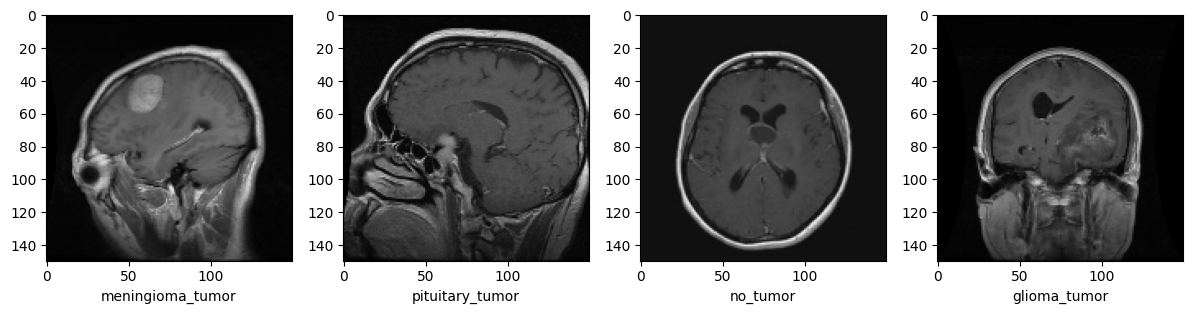

In [35]:
plt.figure(figsize = (15, 15));
for i in range(0, 3000, 906):
  plt.subplot(1, 5, int(i / 906) + 1)
  plt.imshow(train_img[i]);
  plt.xlabel(train_labels[i]);
  plt.tight_layout()

###Shuffling Images and converting to NumPy arrays

In [36]:
train_img, train_labels = shuffle(train_img, train_labels, random_state=42)
train_img = train_img.astype('float32') / 255
train_labels = np.array(pd.get_dummies(train_labels))

###Splitting into testing and training sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(train_img, train_labels, test_size=0.1, random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2937, 150, 150, 3), (2937, 4), (327, 150, 150, 3), (327, 4))

###Data augmentation - creating data variations to improve model

In [38]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range = 35,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True)

datagen.fit(X_train)

train_generator = datagen.flow(X_train, y_train, batch_size = 32)

print("Shape of train: ", train_img.shape)

Shape of train:  (3264, 150, 150, 3)


###CNN model construction and compiling

In [40]:
model = tf.keras.Sequential([
    Conv2D(kernel_size = (5, 5), filters = 32, activation = 'relu', padding = 'same'),
    MaxPooling2D(pool_size = (2, 2)),

    Conv2D(kernel_size = (3, 3), filters = 32, activation = 'relu', padding = 'same'),
    MaxPooling2D(pool_size = (2, 2)),

    Conv2D(kernel_size = (3, 3), filters = 32, activation = 'relu', padding = 'same'),
    MaxPooling2D(pool_size = (2, 2)),

    Conv2D(kernel_size = (3, 3), filters = 64, activation = 'relu', padding = 'same'),
    MaxPooling2D(pool_size = (2, 2)),

    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(rate = 0.5),
    Dense(4, activation = 'softmax')
  ])

model.compile(optimizer = 'adam' , loss = "categorical_crossentropy", metrics=["accuracy"])

model.build(input_shape=(None, 150, 150, 3))
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_22 (Conv2D)          (None, 150, 150, 32)      2432      
                                                                 
 max_pooling2d_14 (MaxPooli  (None, 75, 75, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_23 (Conv2D)          (None, 75, 75, 32)        9248      
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 37, 37, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_24 (Conv2D)          (None, 37, 37, 32)        9248      
                                                                 
 max_pooling2d_16 (MaxPooli  (None, 18, 18, 32)       

###Fitting/Training Model

In [41]:
history = model.fit(X_train, y_train, batch_size = 32, epochs = 20, validation_data = (X_test, y_test), verbose = 1)

Epoch 1/20
92/92 [==============================] - 127s 1s/step - loss: 1.1898 - accuracy: 0.4763 - val_loss: 0.8960 - val_accuracy: 0.6453
Epoch 2/20
92/92 [==============================] - 114s 1s/step - loss: 0.9193 - accuracy: 0.6020 - val_loss: 0.6898 - val_accuracy: 0.7492
Epoch 3/20
92/92 [==============================] - 118s 1s/step - loss: 0.7258 - accuracy: 0.6963 - val_loss: 0.5812 - val_accuracy: 0.7615
Epoch 4/20
92/92 [==============================] - 118s 1s/step - loss: 0.5933 - accuracy: 0.7528 - val_loss: 0.4190 - val_accuracy: 0.8532
Epoch 5/20
92/92 [==============================] - 122s 1s/step - loss: 0.5062 - accuracy: 0.8100 - val_loss: 0.3702 - val_accuracy: 0.8777
Epoch 6/20
92/92 [==============================] - 117s 1s/step - loss: 0.4028 - accuracy: 0.8413 - val_loss: 0.3069 - val_accuracy: 0.8869
Epoch 7/20
92/92 [==============================] - 118s 1s/step - loss: 0.3533 - accuracy: 0.8607 - val_loss: 0.2611 - val_accuracy: 0.9052
Epoch 8/20
92

###Plotting loss and accuracy

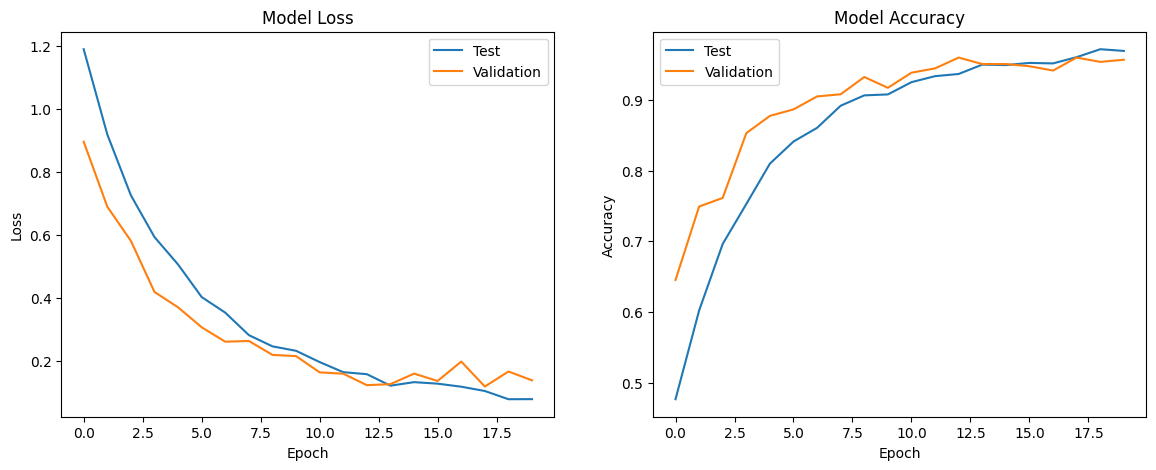

In [42]:
plt.figure(figsize = (14, 5));
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Test', 'Validation'])

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Test', 'Validation'])

plt.show()

###Creating evalution metrics

In [44]:
train_score = model.evaluate(X_train, y_train, verbose=0)
print('Train loss:', train_score[0], 'Train accuracy: ', train_score[1], "\n---------------------------------------------")
test_score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', test_score[0], 'Test accuracy: ', test_score[1])

Train loss: 0.016775788739323616 Train accuracy:  0.9952332377433777 
---------------------------------------------
Test loss: 0.1383938044309616 Test accuracy:  0.9571865200996399


###Summary of precision, recall, f1-score, and support values

In [45]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)
print(classification_report(y_test_new,pred))

11/11 [==============================] - 4s 345ms/step
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        85
           1       0.99      0.90      0.94        99
           2       0.94      0.96      0.95        48
           3       0.97      0.98      0.97        95

    accuracy                           0.96       327
   macro avg       0.96      0.96      0.96       327
weighted avg       0.96      0.96      0.96       327

